# VAE EDA — Phase 3E Checkpoint

Compares preprocessed feature distributions against VAE reconstructions (mean path, no sampling)  
to verify the model has learned a useful latent representation without severe distortion.

**Prerequisite**: run `dvc repro train_vae` before opening this notebook.

| Section | What it shows |
|---|---|
| 1 | Load data & feature names |
| 2 | Load VAE + stale-checkpoint guard |
| 3 | Run mean-path reconstructions |
| 4a | Per-sample MSE histogram |
| 4b | Per-feature MSE bar chart |
| 4c | Real vs reconstructed KDE — numeric features |
| 4d | KS-test table per feature |
| 4e | Latent-space PCA coloured by severity class |
| 4f | Reconstruction MSE boxplot per class |
| 4g | Posterior variance per latent dimension |

In [53]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import yaml
from scipy import stats
from sklearn.decomposition import PCA

from src.train_vae.vae_trainer import Encoder, Decoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

CLASS_NAMES  = ['PDO', 'Injury', 'Fatal']
CLASS_COLORS = ['#4e79a7', '#f28e2b', '#e15759']
PROCESSED    = ROOT / 'data' / 'processed'
MODELS       = ROOT / 'models'

## 1. Load data & feature names

In [54]:
X_train = np.load(PROCESSED / 'X_train.npy')
X_val   = np.load(PROCESSED / 'X_val.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_train = np.load(PROCESSED / 'y_train.npy')
y_val   = np.load(PROCESSED / 'y_val.npy')
y_test  = np.load(PROCESSED / 'y_test.npy')

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

print(f'X_all : {X_all.shape}')
print(f'y_all : {y_all.shape}  class counts → {dict(zip(*np.unique(y_all, return_counts=True)))}')

X_all : (74309, 28)
y_all : (74309,)  class counts → {0: 60761, 1: 13443, 2: 105}


In [55]:
with open(ROOT / 'params.yaml') as f:
    params = yaml.safe_load(f)

fc           = params['features']
numeric_cols = fc['numeric_columns']
ordinal_cols = list(fc['ordinal_columns'].keys())
cyclical_cols = fc.get('cyclical_columns', {})

# Remove cyclical columns from their original groups (HOUR was numeric, MONTH was ordinal)
# They are now replaced by sin/cos pairs in the 'cyc' transformer group
numeric_cols = [c for c in numeric_cols if c not in cyclical_cols]
ordinal_cols = [c for c in ordinal_cols if c not in cyclical_cols]

# Build cyclical column names (sin/cos pairs)
cyc_cols = []
for col in sorted(cyclical_cols.keys()):  # sorted for consistent order
    cyc_cols.extend([f'{col}_sin', f'{col}_cos'])

cat_cols = [c for c in fc['columns'] 
            if c not in fc['numeric_columns'] 
            and c not in fc['ordinal_columns'] 
            and c not in cyclical_cols]

# ColumnTransformer output order: num → cat → cyc → ord
feature_names = numeric_cols + cat_cols + cyc_cols + ordinal_cols
feature_type  = (
    ['numeric']     * len(numeric_cols)
    + ['categorical'] * len(cat_cols)
    + ['cyclical']    * len(cyc_cols)
    + ['ordinal']     * len(ordinal_cols)
)

assert len(feature_names) == X_all.shape[1], (
    f'Feature count mismatch: params has {len(feature_names)}, X_all has {X_all.shape[1]} cols'
)
print('Layout:', {t: feature_type.count(t) for t in ['numeric', 'categorical', 'cyclical', 'ordinal']})
print('Names :', feature_names)

Layout: {'numeric': 8, 'categorical': 15, 'cyclical': 4, 'ordinal': 1}
Names : ['YEAR', 'SPEEDLIMIT', 'RDNUMLANES', 'RDWIDTH', 'DRIVER1AGE', 'DRIVER2AGE', 'X', 'Y', 'WEATHER', 'SURFCOND', 'LIGHTING', 'ROUTECLASS', 'TRUNKLINE', 'RDSUBTYPE', 'DRIVER1SEX', 'DRIVER2SEX', 'VEH1TYPE', 'VEH1USE', 'VEH2TYPE', 'VEH2USE', 'CRASHTYPE', 'TRAFCTLDEV', 'NONTRAFFIC', 'HOUR_sin', 'HOUR_cos', 'MONTH_sin', 'MONTH_cos', 'DAYOFWEEK']


## 2. Load VAE encoder & decoder

In [56]:
enc_ckpt = torch.load(MODELS / 'vae_encoder.pth', weights_only=True)
dec_ckpt = torch.load(MODELS / 'vae_decoder.pth', weights_only=True)

# ── stale-checkpoint guard ────────────────────────────────────────────────────
if enc_ckpt['input_dim'] != X_all.shape[1]:
    raise RuntimeError(
        f"Checkpoint input_dim={enc_ckpt['input_dim']} does not match "
        f"X_all.shape[1]={X_all.shape[1]}.\n"
        "Run `dvc repro train_vae` to rebuild the encoder with current data."
    )

encoder = Encoder(
    input_dim    = enc_ckpt['input_dim'],
    encoder_dims = enc_ckpt['encoder_dims'],
    latent_dim   = enc_ckpt['latent_dim'],
)
encoder.load_state_dict(enc_ckpt['state_dict'])
encoder.eval()

decoder = Decoder(
    latent_dim   = dec_ckpt['latent_dim'],
    decoder_dims = dec_ckpt['decoder_dims'],
    output_dim   = dec_ckpt['output_dim'],
)
decoder.load_state_dict(dec_ckpt['state_dict'])
decoder.eval()

print(f'Encoder  input={enc_ckpt["input_dim"]}  dims={enc_ckpt["encoder_dims"]}  latent={enc_ckpt["latent_dim"]}')
print(f'Decoder  latent={dec_ckpt["latent_dim"]}  dims={dec_ckpt["decoder_dims"]}  output={dec_ckpt["output_dim"]}')

Encoder  input=28  dims=[256, 128, 64]  latent=8
Decoder  latent=8  dims=[64, 128, 256]  output=28


## 3. Run mean-path reconstructions (no sampling)

In [57]:
X_tensor = torch.tensor(X_all, dtype=torch.float32)

with torch.no_grad():
    mu, log_var = encoder(X_tensor)
    X_hat       = decoder(mu)        # reconstruct from mean — no reparameterisation noise

Z   = mu.numpy()       # (N, latent_dim)
X_r = X_hat.numpy()   # (N, n_features)
lv  = log_var.numpy() # (N, latent_dim)

print(f'Latent codes Z  : {Z.shape}')
print(f'Reconstructions : {X_r.shape}')

Latent codes Z  : (74309, 8)
Reconstructions : (74309, 28)


## 4a. Per-sample MSE histogram

Overall RMSE : 1.0892
Mean MSE     : 1.1863
Median MSE   : 0.9672
P95 MSE      : 2.6404


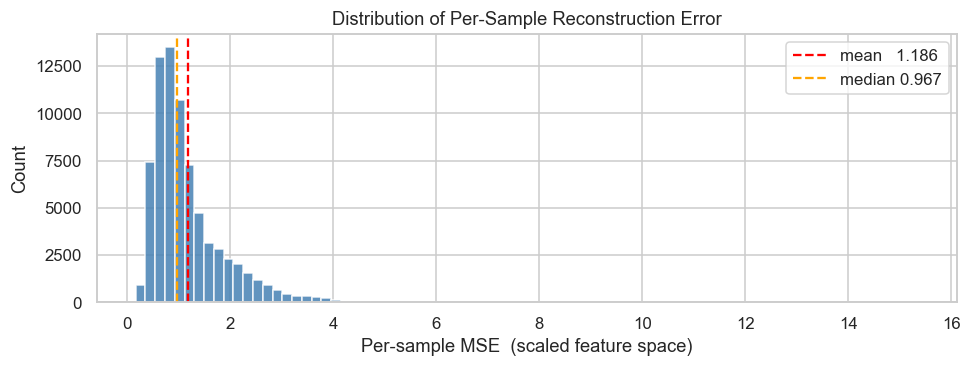

In [58]:
mse_per_sample = np.mean((X_all - X_r) ** 2, axis=1)
overall_rmse   = float(np.sqrt(mse_per_sample.mean()))

print(f'Overall RMSE : {overall_rmse:.4f}')
print(f'Mean MSE     : {mse_per_sample.mean():.4f}')
print(f'Median MSE   : {np.median(mse_per_sample):.4f}')
print(f'P95 MSE      : {np.percentile(mse_per_sample, 95):.4f}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(mse_per_sample, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(mse_per_sample.mean(),      color='red',    linestyle='--', linewidth=1.5,
           label=f'mean   {mse_per_sample.mean():.3f}')
ax.axvline(np.median(mse_per_sample),  color='orange', linestyle='--', linewidth=1.5,
           label=f'median {np.median(mse_per_sample):.3f}')
ax.set_xlabel('Per-sample MSE  (scaled feature space)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Per-Sample Reconstruction Error')
ax.legend()
plt.tight_layout()
plt.show()

## 4b. Per-feature MSE bar chart

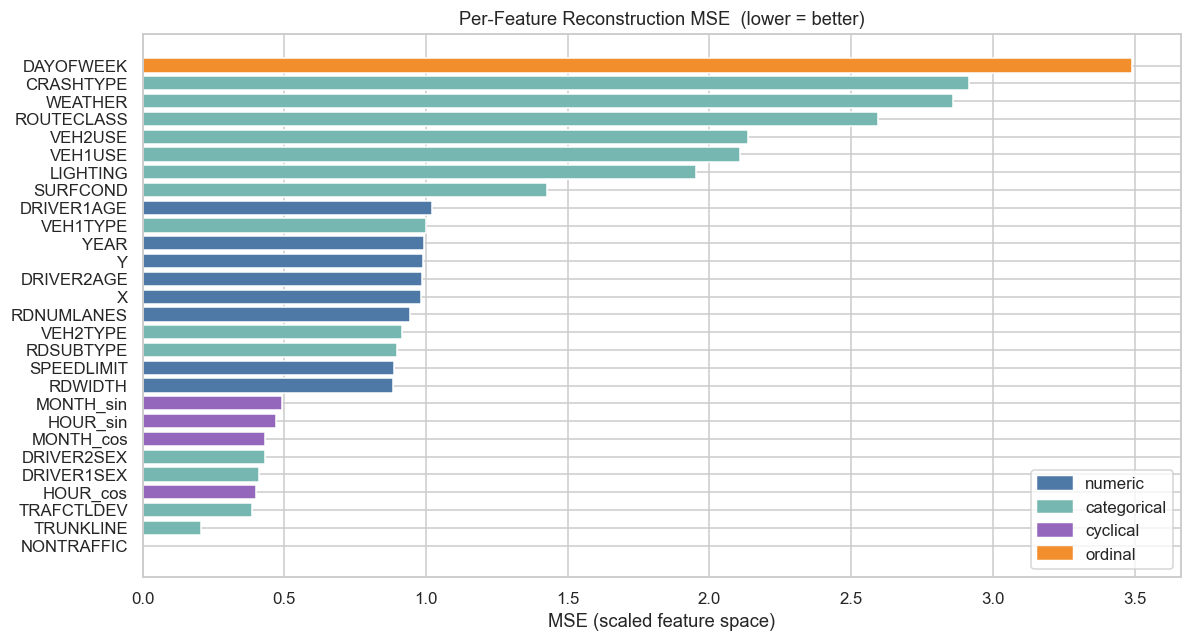

,feature,type,mse,rmse
0,DAYOFWEEK,ordinal,3.4904,1.8683
1,CRASHTYPE,categorical,2.9151,1.7074
2,WEATHER,categorical,2.8607,1.6914
3,ROUTECLASS,categorical,2.5932,1.6103
4,VEH2USE,categorical,2.1357,1.4614
5,VEH1USE,categorical,2.1092,1.4523
6,LIGHTING,categorical,1.9508,1.3967
7,SURFCOND,categorical,1.4260,1.1941
8,DRIVER1AGE,numeric,1.0209,1.0104
9,VEH1TYPE,categorical,0.9994,0.9997


In [59]:
feat_mse  = np.mean((X_all - X_r) ** 2, axis=0)
feat_rmse = np.sqrt(feat_mse)

TYPE_COLOR = {
    'numeric': '#4e79a7', 
    'categorical': '#76b7b2', 
    'cyclical': '#9467bd',
    'ordinal': '#f28e2b'
}

mse_df = (
    pd.DataFrame({'feature': feature_names, 'type': feature_type,
                  'mse': feat_mse, 'rmse': feat_rmse})
    .sort_values('mse', ascending=False)
    .reset_index(drop=True)
)
colors = mse_df['type'].map(TYPE_COLOR)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(mse_df['feature'][::-1], mse_df['mse'][::-1],
        color=list(colors[::-1]), edgecolor='white')
ax.set_xlabel('MSE (scaled feature space)')
ax.set_title('Per-Feature Reconstruction MSE  (lower = better)')
handles = [mpatches.Patch(color=v, label=k) for k, v in TYPE_COLOR.items()]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

display(
    mse_df.head(10)
    .style.format({'mse': '{:.4f}', 'rmse': '{:.4f}'})
    .background_gradient(subset=['mse'], cmap='Reds')
    .set_caption('Top-10 features by reconstruction MSE')
)

## 4c. Real vs reconstructed KDE — numeric features

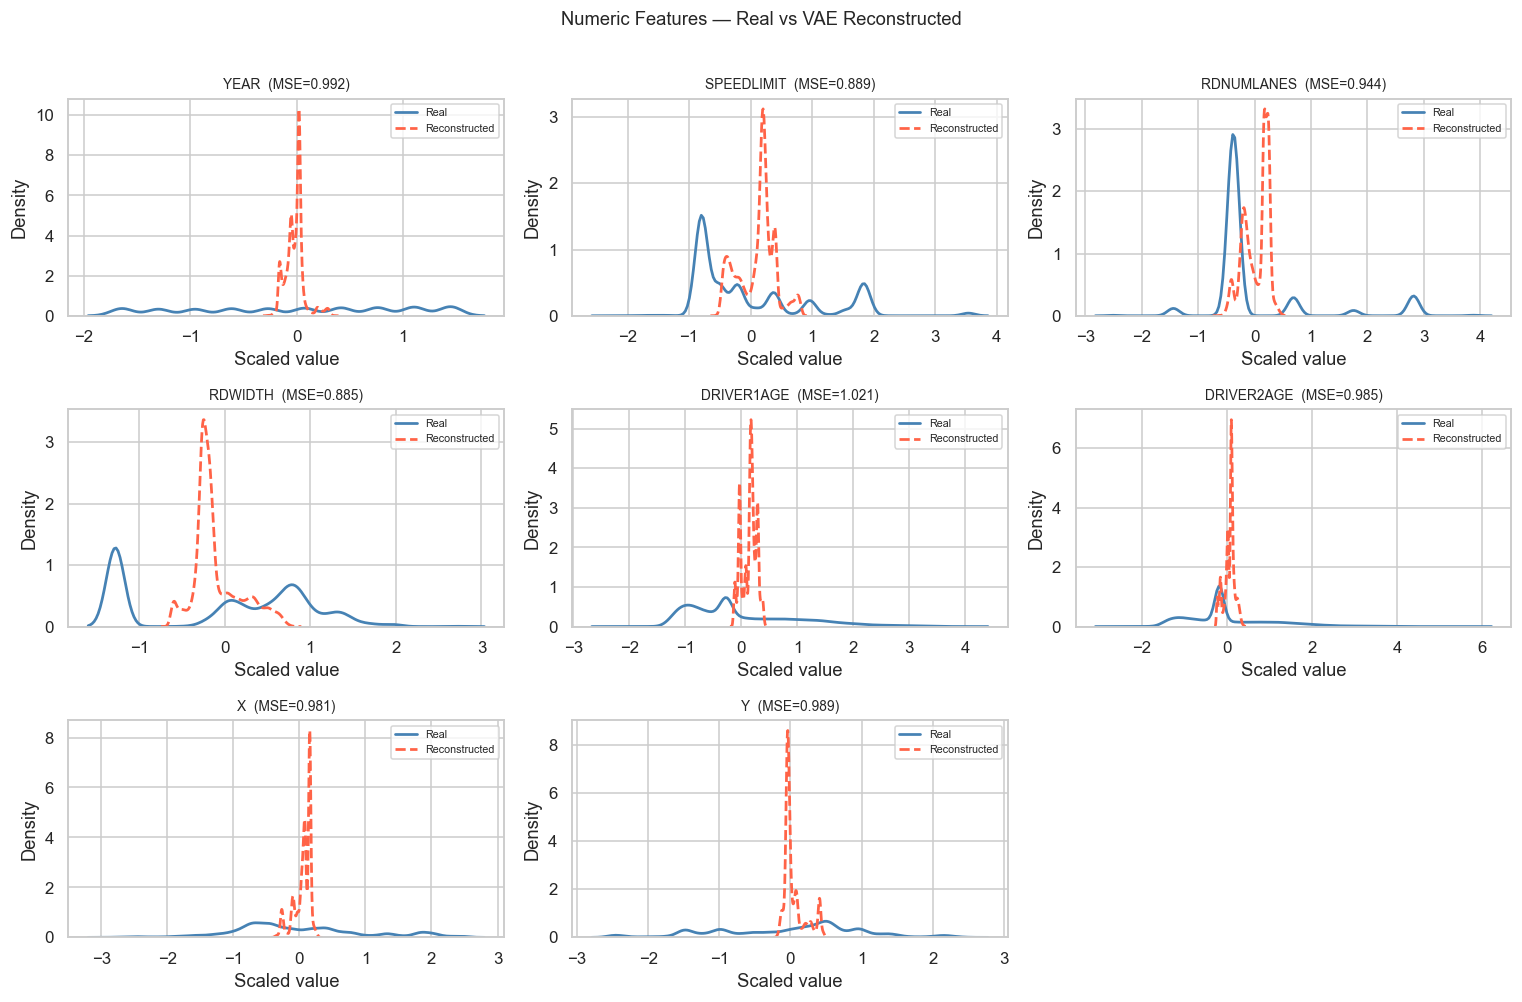

In [60]:
numeric_idx = [i for i, t in enumerate(feature_type) if t == 'numeric']
ncols = 3
nrows = (len(numeric_idx) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes_flat = axes.flatten()

for plot_i, feat_i in enumerate(numeric_idx):
    ax = axes_flat[plot_i]
    sns.kdeplot(X_all[:, feat_i], ax=ax, label='Real',           color='steelblue', linewidth=1.8)
    sns.kdeplot(X_r[:, feat_i],   ax=ax, label='Reconstructed',  color='tomato',    linewidth=1.8, linestyle='--')
    mse_val = float(np.mean((X_all[:, feat_i] - X_r[:, feat_i]) ** 2))
    ax.set_title(f'{feature_names[feat_i]}  (MSE={mse_val:.3f})', fontsize=9)
    ax.set_xlabel('Scaled value')
    ax.legend(fontsize=7)

for ax in axes_flat[len(numeric_idx):]:
    ax.set_visible(False)

fig.suptitle('Numeric Features — Real vs VAE Reconstructed', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 4d. KS-test table per feature

In [61]:
ks_rows = []
for i, name in enumerate(feature_names):
    res = stats.ks_2samp(X_all[:, i], X_r[:, i])
    ks_rows.append({
        'feature' : name,
        'type'    : feature_type[i],
        'mse'     : round(float(feat_mse[i]), 4),
        'ks_stat' : round(res.statistic, 4),
        'p_value' : round(res.pvalue, 6),
    })

ks_df = pd.DataFrame(ks_rows).sort_values('ks_stat', ascending=False).reset_index(drop=True)

print(f'KS stat < 0.05 (well matched) : {(ks_df["ks_stat"] < 0.05).sum()} / {len(ks_df)}')
print(f'KS stat > 0.20 (distribution gap) : {(ks_df["ks_stat"] > 0.20).sum()} / {len(ks_df)}')

display(
    ks_df.style
    .format({'mse': '{:.4f}', 'ks_stat': '{:.4f}', 'p_value': '{:.4e}'})
    .background_gradient(subset=['ks_stat'], cmap='YlOrRd')
    .set_caption('KS test: real vs reconstructed per feature')
)

KS stat < 0.05 (well matched) : 0 / 28
KS stat > 0.20 (distribution gap) : 27 / 28


,feature,type,mse,ks_stat,p_value
0,TRAFCTLDEV,categorical,0.3875,0.8574,0.0000e+00
1,VEH1USE,categorical,2.1092,0.8083,0.0000e+00
2,RDNUMLANES,numeric,0.9441,0.7550,0.0000e+00
3,LIGHTING,categorical,1.9508,0.7071,0.0000e+00
4,DRIVER2AGE,numeric,0.9851,0.6010,0.0000e+00
5,DRIVER1AGE,numeric,1.0209,0.5995,0.0000e+00
6,SURFCOND,categorical,1.4260,0.5987,0.0000e+00
7,ROUTECLASS,categorical,2.5932,0.5981,0.0000e+00
8,VEH2USE,categorical,2.1357,0.5905,0.0000e+00
9,TRUNKLINE,categorical,0.2061,0.5861,0.0000e+00


## 4e. Latent-space PCA — coloured by crash severity

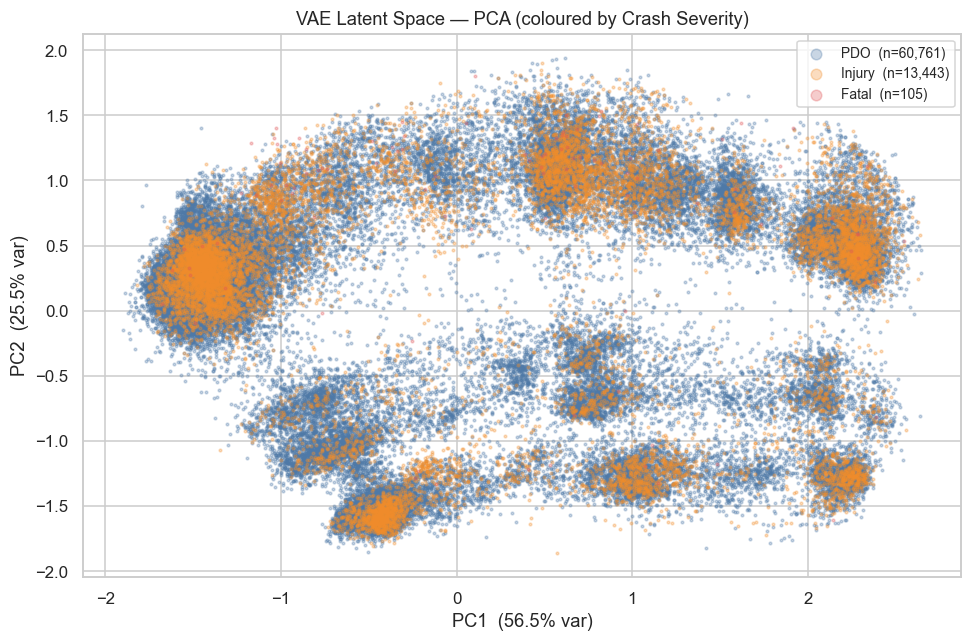

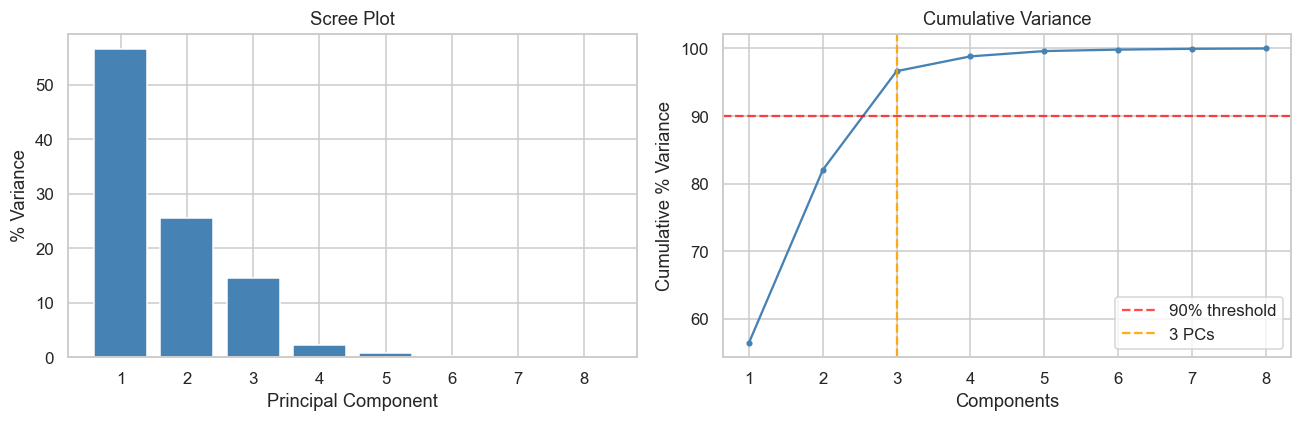

PC1+PC2 explain 82.0%   |   3 components for 90%


In [62]:
pca     = PCA(n_components=2, random_state=42)
Z_pca   = pca.fit_transform(Z)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
for cls_id, (cls_name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = y_all == cls_id
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1],
               s=3, alpha=0.3, color=color, label=f'{cls_name}  (n={mask.sum():,})')
ax.set_xlabel(f'PC1  ({var_exp[0]:.1f}% var)')
ax.set_ylabel(f'PC2  ({var_exp[1]:.1f}% var)')
ax.set_title('VAE Latent Space — PCA (coloured by Crash Severity)')
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.show()

# scree + cumulative variance
pca_full = PCA(random_state=42).fit(Z)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_90     = int(np.searchsorted(cum_var, 90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(cum_var) + 1), pca_full.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('% Variance')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cum_var) + 1), cum_var, marker='o', markersize=3, color='steelblue')
axes[1].axhline(90, color='red',    linestyle='--', alpha=0.7, label='90% threshold')
axes[1].axvline(n_90, color='orange', linestyle='--', alpha=0.9, label=f'{n_90} PCs')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative % Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'PC1+PC2 explain {sum(var_exp):.1f}%   |   {n_90} components for 90%')

## 4f. Reconstruction MSE boxplot per severity class

,class,n,mean_mse,median_mse,p95_mse,rmse
0,PDO,60761,1.2017,0.9776,2.6812,1.0962
1,Injury,13443,1.1158,0.9241,2.4160,1.0563
2,Fatal,105,1.2926,1.0869,2.9837,1.1369


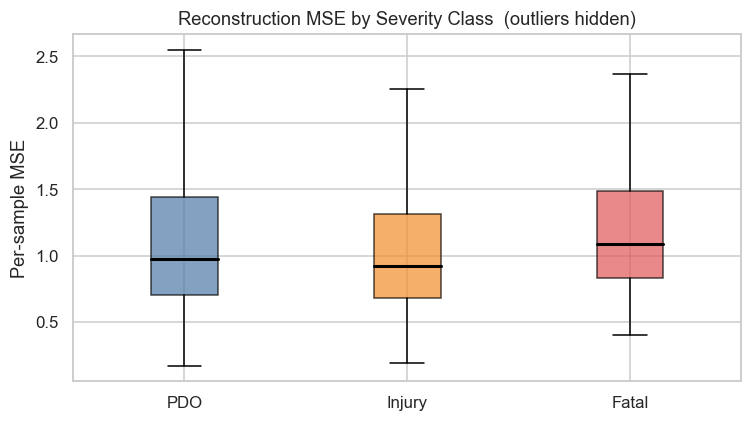

In [63]:
class_mse = {name: mse_per_sample[y_all == i] for i, name in enumerate(CLASS_NAMES)}

rows = [
    {'class': name, 'n': len(v), 'mean_mse': round(v.mean(), 4),
     'median_mse': round(float(np.median(v)), 4),
     'p95_mse': round(float(np.percentile(v, 95)), 4),
     'rmse': round(float(np.sqrt(v.mean())), 4)}
    for name, v in class_mse.items()
]
class_mse_df = pd.DataFrame(rows)

display(
    class_mse_df.style
    .format({'mean_mse': '{:.4f}', 'median_mse': '{:.4f}', 'p95_mse': '{:.4f}', 'rmse': '{:.4f}'})
    .background_gradient(subset=['mean_mse', 'rmse'], cmap='YlOrRd')
    .set_caption('Reconstruction MSE per crash severity class')
)

fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [class_mse[n] for n in CLASS_NAMES],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    showfliers=False,
)
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(CLASS_NAMES) + 1))
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Per-sample MSE')
ax.set_title('Reconstruction MSE by Severity Class  (outliers hidden)')
plt.tight_layout()
plt.show()

## 4g. Posterior variance per latent dimension

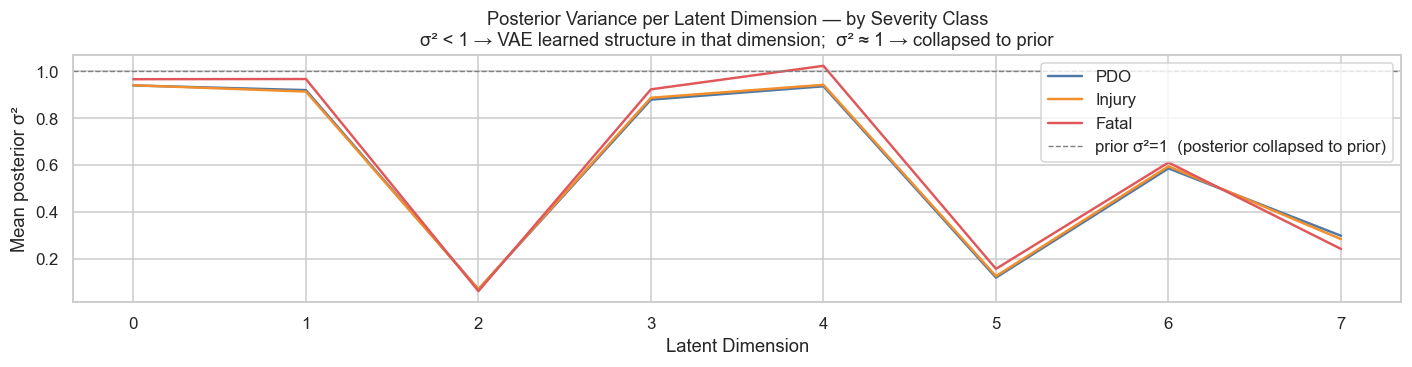

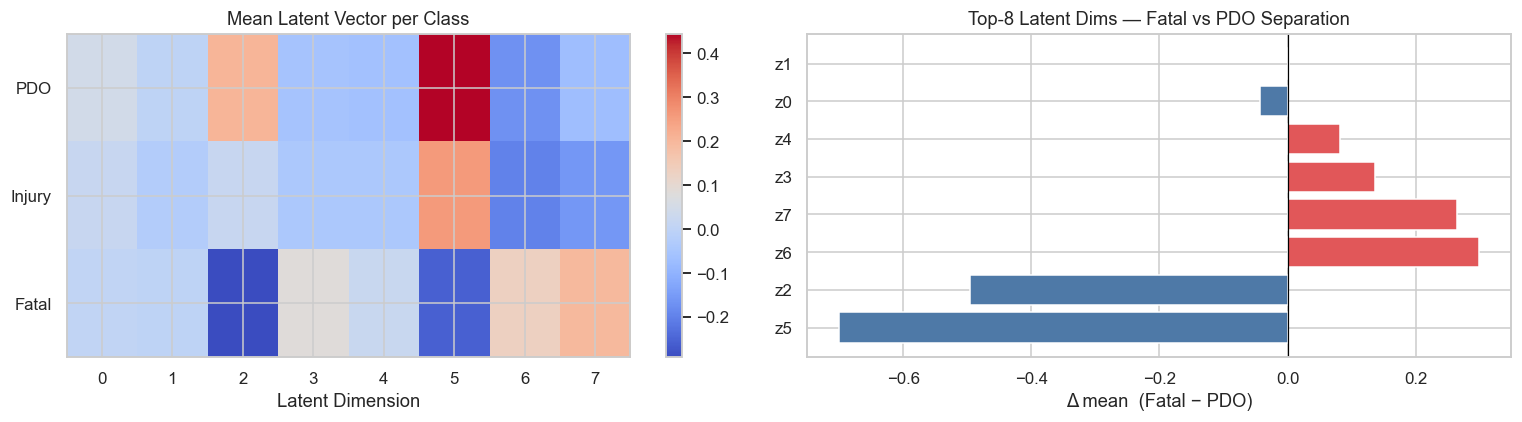

In [64]:
# Per-class mean posterior σ² = exp(log_var)
class_var = np.stack([
    np.exp(lv[y_all == cls_id]).mean(axis=0)
    for cls_id in range(len(CLASS_NAMES))
])  # (3, latent_dim)

fig, ax = plt.subplots(figsize=(13, 3.5))
for cls_id, (cls_name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    ax.plot(class_var[cls_id], label=cls_name, color=color, linewidth=1.6)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.9,
           label='prior σ²=1  (posterior collapsed to prior)')
ax.set_xlabel('Latent Dimension')
ax.set_ylabel('Mean posterior σ²')
ax.set_title(
    'Posterior Variance per Latent Dimension — by Severity Class\n'
    'σ² < 1 → VAE learned structure in that dimension;  σ² ≈ 1 → collapsed to prior'
)
ax.legend()
plt.tight_layout()
plt.show()

# Fatal vs PDO mean latent separation
class_means  = np.stack([Z[y_all == i].mean(axis=0) for i in range(len(CLASS_NAMES))])
fatal_vs_pdo = class_means[2] - class_means[0]
top_n        = min(20, Z.shape[1])
sorted_idx   = np.argsort(np.abs(fatal_vs_pdo))[::-1][:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(class_means, aspect='auto', cmap='coolwarm')
axes[0].set_yticks(range(len(CLASS_NAMES)))
axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_xlabel('Latent Dimension')
axes[0].set_title('Mean Latent Vector per Class')
plt.colorbar(im, ax=axes[0])

axes[1].barh(
    range(top_n), fatal_vs_pdo[sorted_idx],
    color=[('#e15759' if v > 0 else '#4e79a7') for v in fatal_vs_pdo[sorted_idx]]
)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([f'z{d}' for d in sorted_idx])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Δ mean  (Fatal − PDO)')
axes[1].set_title(f'Top-{top_n} Latent Dims — Fatal vs PDO Separation')
plt.tight_layout()
plt.show()

---
# Report

The three sections below directly satisfy the checkpoint reporting requirements.

## Summary Statistics

Printed metrics comparing original input features to reconstructed outputs.

In [65]:
fatal_mean_mse = class_mse_df.loc[class_mse_df['class'] == 'Fatal', 'mean_mse'].values[0]

# ── overall metrics ───────────────────────────────────────────────────────────
overall = pd.DataFrame([
    ('Total samples',             f'{len(X_all):,}'),
    ('Feature count',             str(X_all.shape[1])),
    ('Latent dim',                str(Z.shape[1])),
    ('Overall RMSE',              f'{overall_rmse:.4f}'),
    ('Mean per-sample MSE',       f'{mse_per_sample.mean():.4f}'),
    ('Median per-sample MSE',     f'{np.median(mse_per_sample):.4f}'),
    ('P95 per-sample MSE',        f'{np.percentile(mse_per_sample, 95):.4f}'),
    ('Features KS < 0.05',        f'{(ks_df["ks_stat"] < 0.05).sum()} / {len(ks_df)}'),
    ('Features KS > 0.20',        f'{(ks_df["ks_stat"] > 0.20).sum()} / {len(ks_df)}'),
    ('Worst-matched feature',     ks_df.iloc[0]['feature']),
    ('Best-matched feature',      ks_df.iloc[-1]['feature']),
    ('PCA dims for 90% variance', f'{n_90} / {Z.shape[1]}'),
    ('Fatal class mean MSE',      f'{fatal_mean_mse:.4f}'),
], columns=['Metric', 'Value'])
display(overall.style.set_caption('Overall reconstruction metrics').hide(axis='index'))

# ── per-feature: mean and std of real vs reconstructed ───────────────────────
records = []
for i, name in enumerate(feature_names):
    real  = X_all[:, i]
    recon = X_r[:, i]
    records.append({
        'feature'    : name,
        'type'       : feature_type[i],
        'real_mean'  : round(float(real.mean()),  4),
        'recon_mean' : round(float(recon.mean()), 4),
        'Δ_mean'     : round(float(recon.mean() - real.mean()), 4),
        'real_std'   : round(float(real.std()),   4),
        'recon_std'  : round(float(recon.std()),  4),
        'Δ_std'      : round(float(recon.std()  - real.std()),  4),
        'mse'        : round(float(feat_mse[i]),  4),
        'ks_stat'    : ks_df.loc[ks_df['feature'] == name, 'ks_stat'].values[0],
    })

stats_df = pd.DataFrame(records).sort_values('mse', ascending=False).reset_index(drop=True)
display(
    stats_df.style
    .format({'real_mean': '{:.4f}', 'recon_mean': '{:.4f}', 'Δ_mean': '{:+.4f}',
             'real_std':  '{:.4f}', 'recon_std':  '{:.4f}', 'Δ_std':  '{:+.4f}',
             'mse': '{:.4f}', 'ks_stat': '{:.4f}'})
    .background_gradient(subset=['mse', 'ks_stat'], cmap='YlOrRd')
    .set_caption('Per-feature: real vs reconstructed mean / std (sorted by MSE)')
)

Metric,Value
Total samples,"74,309"
Feature count,28
Latent dim,8
Overall RMSE,1.0892
Mean per-sample MSE,1.1863
Median per-sample MSE,0.9672
P95 per-sample MSE,2.6404
Features KS < 0.05,0 / 28
Features KS > 0.20,27 / 28
Worst-matched feature,TRAFCTLDEV


,feature,type,real_mean,recon_mean,Δ_mean,real_std,recon_std,Δ_std,mse,ks_stat
0,DAYOFWEEK,ordinal,2.8458,2.7764,-0.0694,1.8874,0.1776,-1.7097,3.4904,0.4487
1,CRASHTYPE,categorical,13.0766,13.0105,-0.0661,8.1395,7.5847,-0.5548,2.9151,0.1722
2,WEATHER,categorical,2.4834,2.4436,-0.0399,2.3327,1.3614,-0.9714,2.8607,0.4971
3,ROUTECLASS,categorical,2.2474,2.4245,+0.1772,1.7022,0.4090,-1.2931,2.5932,0.5981
4,VEH2USE,categorical,7.4037,7.3921,-0.0116,1.8826,1.1658,-0.7168,2.1357,0.5905
5,VEH1USE,categorical,6.8666,6.7865,-0.0800,1.4649,0.1716,-1.2934,2.1092,0.8083
6,LIGHTING,categorical,2.2823,2.1002,-0.1820,1.4097,0.3031,-1.1066,1.9508,0.7071
7,SURFCOND,categorical,3.6449,4.0702,+0.4253,4.0301,3.9753,-0.0547,1.4260,0.5987
8,DRIVER1AGE,numeric,0.0001,0.1397,+0.1396,1.0003,0.1319,-0.8684,1.0209,0.5995
9,VEH1TYPE,categorical,5.1549,5.0663,-0.0886,1.0055,0.3185,-0.6870,0.9994,0.4703


### MAPE per feature

MAPE is computed only on samples where `|real| > 0.01` to avoid division-by-zero on near-zero scaled values.  
Features whose non-zero fraction is below 10 % are flagged as unreliable.

Overall mean MAPE (reliable features only): 69.63 %
Reliable features: 27 / 28


,feature,type,mape_%,non_zero_frac,reliable,mse
0,RDWIDTH,numeric,164.52,1.000,True,0.8847
1,DRIVER1AGE,numeric,135.68,1.000,True,1.0209
2,Y,numeric,115.47,0.996,True,0.9892
3,X,numeric,110.75,0.997,True,0.9810
4,SPEEDLIMIT,numeric,107.64,1.000,True,0.8885
5,YEAR,numeric,104.12,1.000,True,0.9920
6,DRIVER2AGE,numeric,103.81,1.000,True,0.9851
7,RDNUMLANES,numeric,101.60,1.000,True,0.9441
8,MONTH_sin,cyclical,98.99,0.828,True,0.4931
9,HOUR_sin,cyclical,91.67,0.916,True,0.4724


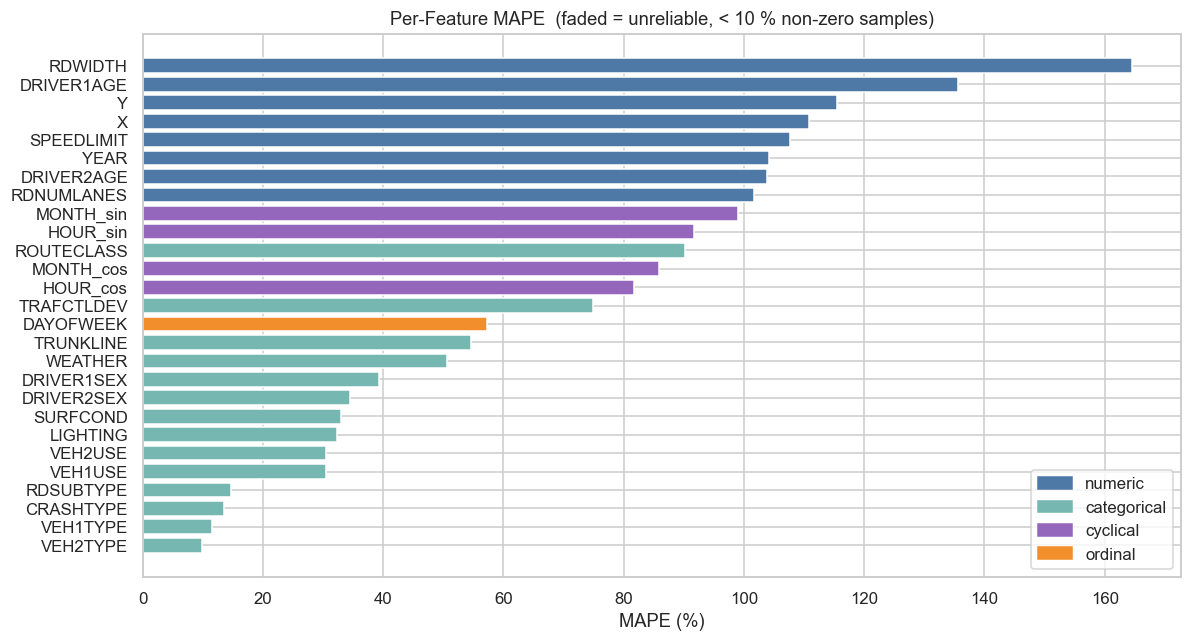

In [66]:
EPS = 0.01   # minimum |real| to include a sample in MAPE

mape_rows = []
for i, name in enumerate(feature_names):
    real  = X_all[:, i]
    recon = X_r[:, i]
    mask  = np.abs(real) > EPS
    nz_frac = mask.mean()
    if mask.sum() == 0:
        mape = np.nan
    else:
        mape = float(np.mean(np.abs(real[mask] - recon[mask]) / np.abs(real[mask])) * 100)
    mape_rows.append({
        'feature'       : name,
        'type'          : feature_type[i],
        'mape_%'        : round(mape, 2) if not np.isnan(mape) else np.nan,
        'non_zero_frac' : round(nz_frac, 3),
        'reliable'      : nz_frac >= 0.10,
        'mse'           : round(float(feat_mse[i]), 4),
    })

mape_df = pd.DataFrame(mape_rows).sort_values('mape_%', ascending=False).reset_index(drop=True)

# ── summary line ──────────────────────────────────────────────────────────────
reliable = mape_df[mape_df['reliable']]
print(f'Overall mean MAPE (reliable features only): {reliable["mape_%"].mean():.2f} %')
print(f'Reliable features: {len(reliable)} / {len(mape_df)}')

display(
    mape_df.style
    .format({'mape_%': '{:.2f}', 'non_zero_frac': '{:.3f}', 'mse': '{:.4f}'},
            na_rep='—')
    .background_gradient(subset=['mape_%'], cmap='YlOrRd')
    .apply(lambda col: ['background-color: #f0f0f0' if not v else '' for v in mape_df['reliable']],
           subset=['mape_%'])
    .set_caption('Per-feature MAPE  (grey = unreliable: < 10 % non-zero samples)')
)

# ── bar chart ─────────────────────────────────────────────────────────────────
TYPE_COLOR = {
    'numeric': '#4e79a7', 
    'categorical': '#76b7b2', 
    'cyclical': '#9467bd',
    'ordinal': '#f28e2b'
}
plot_df    = mape_df.dropna(subset=['mape_%']).sort_values('mape_%')
bar_colors = [TYPE_COLOR[t] for t in plot_df['type']]
bar_alpha  = [1.0 if r else 0.35 for r in plot_df['reliable']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(plot_df['feature'], plot_df['mape_%'], color=bar_colors, edgecolor='white')
for bar, alpha in zip(bars, bar_alpha):
    bar.set_alpha(alpha)

ax.set_xlabel('MAPE (%)')
ax.set_title('Per-Feature MAPE  (faded = unreliable, < 10 % non-zero samples)')
handles = [mpatches.Patch(color=v, label=k) for k, v in TYPE_COLOR.items()]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

## Feature Distributions

Histograms / density plots showing original vs reconstructed data overlap — all 26 features.

C:\Users\loren\AppData\Local\Temp\ipykernel_38476\2482135275.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_all[:, i], ax=ax, color='steelblue', linewidth=1.6, label='Real')


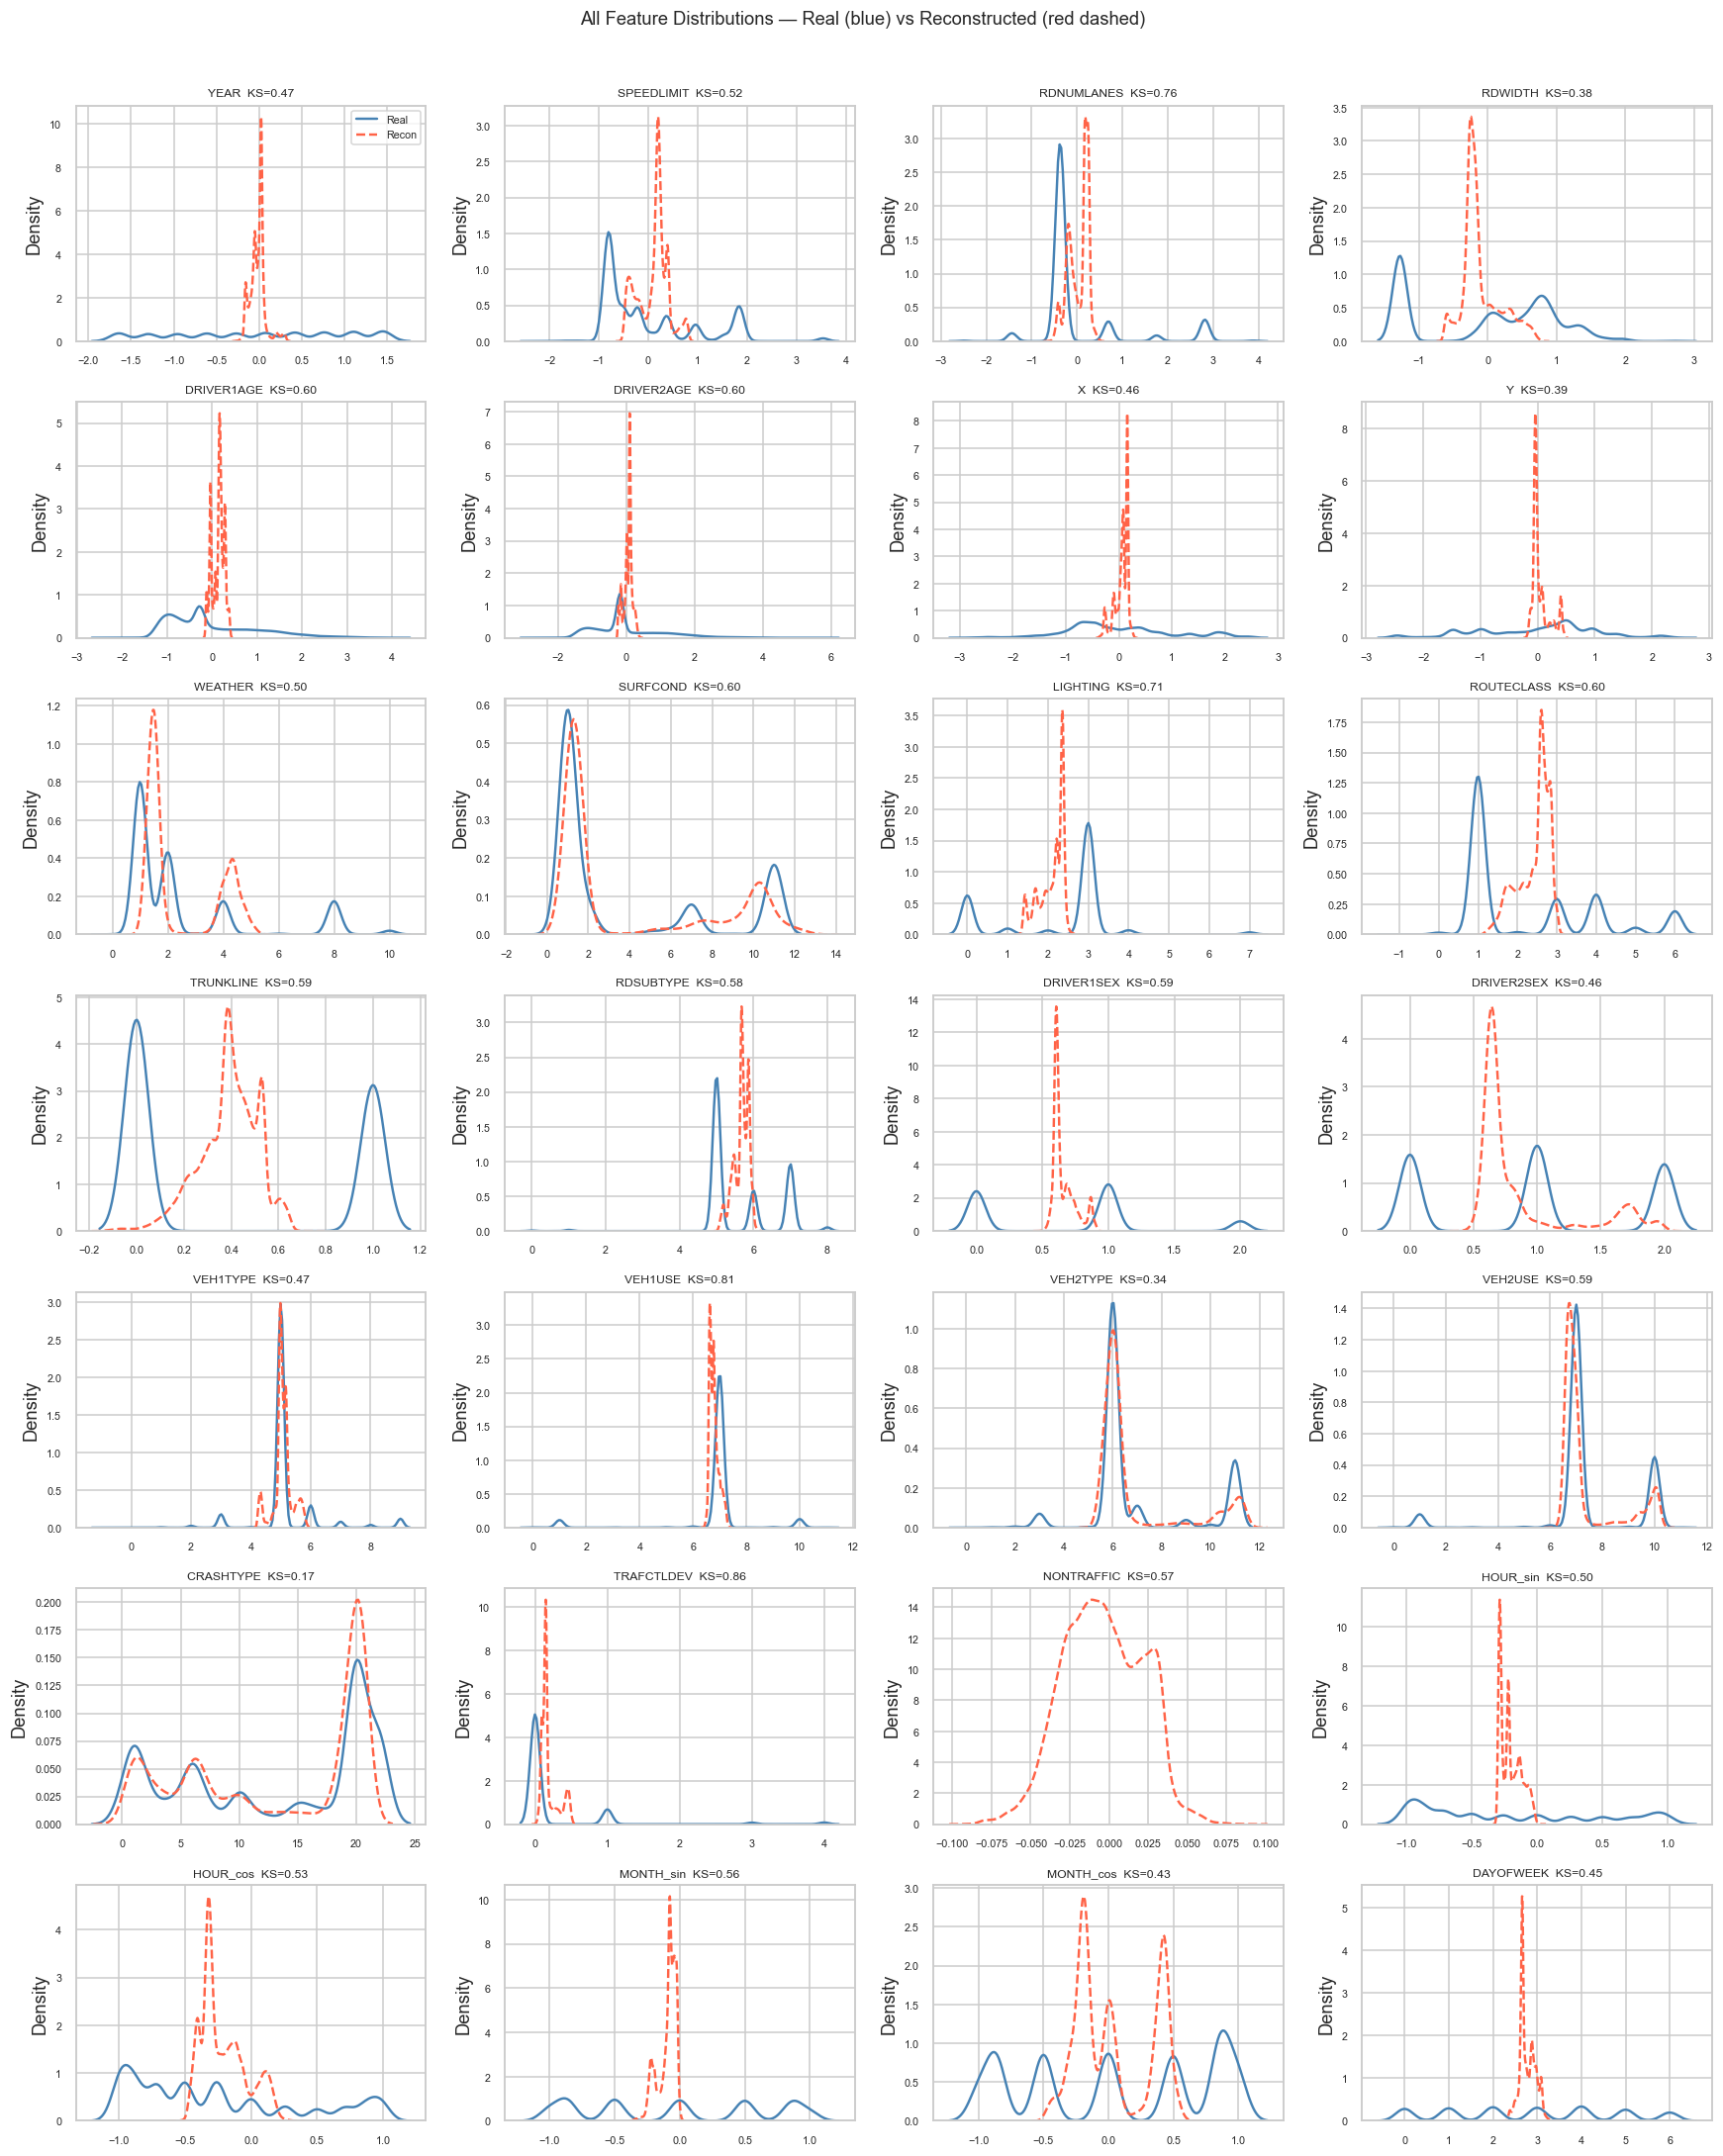

In [67]:
ncols = 4
nrows = (len(feature_names) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.8))
axes_flat = axes.flatten()

for i, name in enumerate(feature_names):
    ax = axes_flat[i]
    sns.kdeplot(X_all[:, i], ax=ax, color='steelblue', linewidth=1.6, label='Real')
    sns.kdeplot(X_r[:, i],   ax=ax, color='tomato',    linewidth=1.6, linestyle='--', label='Recon')
    ks_val = ks_df.loc[ks_df['feature'] == name, 'ks_stat'].values[0]
    ax.set_title(f'{name}  KS={ks_val:.2f}', fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)
    else:
        leg = ax.get_legend()
        if leg:
            leg.remove()

for ax in axes_flat[len(feature_names):]:
    ax.set_visible(False)

fig.suptitle('All Feature Distributions — Real (blue) vs Reconstructed (red dashed)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Latent Space Visualizations

PCA and t-SNE scatter plots coloured by crash severity class to check for distinct clustering.

Running t-SNE on 8,000 samples …
Done.


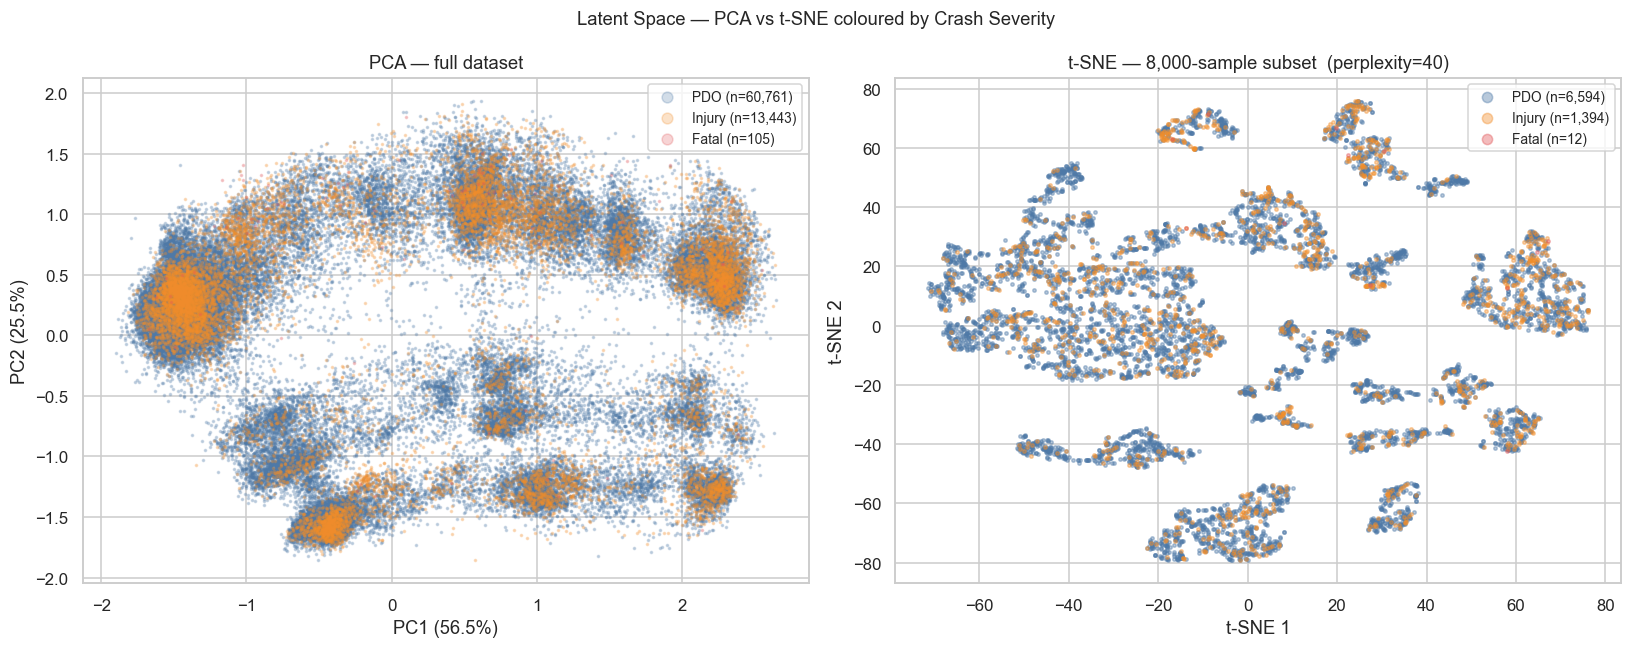

In [68]:
from sklearn.manifold import TSNE

# t-SNE on a stratified subsample (full 74k takes several minutes)
N_TSNE = 8000
rng_ts = np.random.default_rng(42)
idx    = rng_ts.choice(len(Z), size=N_TSNE, replace=False)
Z_sub  = Z[idx]
y_sub  = y_all[idx]

print(f'Running t-SNE on {N_TSNE:,} samples …')
Z_tsne = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(Z_sub)
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA (full dataset, already computed)
for cls_id, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = y_all == cls_id
    axes[0].scatter(Z_pca[mask, 0], Z_pca[mask, 1],
                    s=2, alpha=0.25, color=color, label=f'{name} (n={mask.sum():,})')
axes[0].set_title('PCA — full dataset')
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1f}%)')
axes[0].legend(markerscale=5, fontsize=9)

# t-SNE (subsample)
for cls_id, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = y_sub == cls_id
    axes[1].scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                    s=5, alpha=0.4, color=color, label=f'{name} (n={mask.sum():,})')
axes[1].set_title(f't-SNE — {N_TSNE:,}-sample subset  (perplexity=40)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(markerscale=3, fontsize=9)

fig.suptitle('Latent Space — PCA vs t-SNE coloured by Crash Severity', fontsize=12)
plt.tight_layout()
plt.show()